Con base en el programa Clase_NNA3, desarrolle dos redes neuronales con 2 capas oculta, una
que aprenda a reconocer una compuerta NAND y la otra aprenda a reconocer una compuerta
XOR.

=== Entrenando red para NAND ===
Época 0, pérdida: 0.475203
Época 2000, pérdida: 0.103497
Época 4000, pérdida: 0.002378
Época 6000, pérdida: 0.000924
Época 8000, pérdida: 0.000552

Resultados NAND:
[0 0] -> 1 (esperado: 1)
[0 1] -> 1 (esperado: 1)
[1 0] -> 1 (esperado: 1)
[1 1] -> 0 (esperado: 0)

=== Entrenando red para XOR ===
Época 0, pérdida: 0.332501
Época 2000, pérdida: 0.249979
Época 4000, pérdida: 0.249962
Época 6000, pérdida: 0.249917
Época 8000, pérdida: 0.249716

Resultados XOR:
[0 0] -> 0 (esperado: 0)
[0 1] -> 1 (esperado: 1)
[1 0] -> 1 (esperado: 1)
[1 1] -> 1 (esperado: 0)


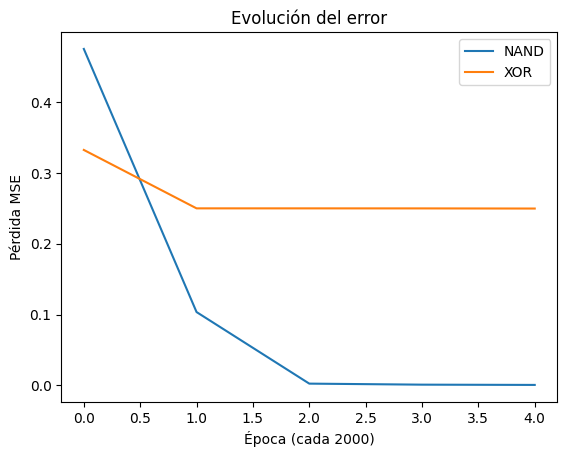

In [3]:
import numpy as np
import matplotlib.pyplot as plt

def sig(s):
    return 1/(1+np.exp(-s))

def dSig(s):
    ds = sig(s) * (1 - sig(s))
    return ds

def propaga(X, W1, b1, W2, b2, W3, b3):
    # Capa 1
    Z1 = np.dot(X, W1) + b1
    A1 = sig(Z1)
    # Capa 2
    Z2 = np.dot(A1, W2) + b2
    A2 = sig(Z2)
    # Capa de salida
    Z3 = np.dot(A2, W3) + b3
    A3 = sig(Z3)
    return A3, Z3, A2, Z2, A1, Z1

def backpropagation(X, Yr, A3, Z3, A2, Z2, A1, Z1, W3, b3, W2, b2, W1, b1, lr):
    m = X.shape[0]  # número de ejemplos

    # Error en la salida
    error = A3 - Yr.reshape(-1,1)

    # Delta capa salida
    delta3 = error * dSig(Z3)
    dW3 = np.dot(A2.T, delta3) / m
    db3 = np.sum(delta3, axis=0) / m

    # Delta capa oculta 2
    delta2 = np.dot(delta3, W3.T) * dSig(Z2)
    dW2 = np.dot(A1.T, delta2) / m
    db2 = np.sum(delta2, axis=0) / m

    # Delta capa oculta 1
    delta1 = np.dot(delta2, W2.T) * dSig(Z1)
    dW1 = np.dot(X.T, delta1) / m
    db1 = np.sum(delta1, axis=0) / m

    # Actualizar pesos
    W3 -= lr * dW3
    b3 -= lr * db3
    W2 -= lr * dW2
    b2 -= lr * db2
    W1 -= lr * dW1
    b1 -= lr * db1

    return W1, b1, W2, b2, W3, b3

# -------------------------------
# Datos comunes
# -------------------------------
X = np.array([[0,0],
              [0,1],
              [1,0],
              [1,1]])

# Salidas para NAND y XOR
Y_nand = np.array([1, 1, 1, 0])
Y_xor  = np.array([0, 1, 1, 0])

# -------------------------------
# Función para entrenar una red
# -------------------------------
def entrenar_red(X, Y, nn_0, nn_1, nn_2, lr=0.5, epocas=10000, imprimir_cada=2000):
    # Inicializar pesos aleatorios pequeños
    np.random.seed(42)  # para reproducibilidad
    W1 = np.random.randn(nn_0, nn_1) * 0.5
    b1 = np.random.randn(nn_1) * 0.5
    W2 = np.random.randn(nn_1, nn_1) * 0.5   # segunda capa oculta
    b2 = np.random.randn(nn_1) * 0.5
    W3 = np.random.randn(nn_1, nn_2) * 0.5
    b3 = np.random.randn(nn_2) * 0.5

    perdidas = []
    for i in range(epocas):
        A3, Z3, A2, Z2, A1, Z1 = propaga(X, W1, b1, W2, b2, W3, b3)
        loss = np.mean((A3.flatten() - Y)**2)
        if i % imprimir_cada == 0:
            perdidas.append(loss)
            print(f"Época {i}, pérdida: {loss:.6f}")
        W1, b1, W2, b2, W3, b3 = backpropagation(X, Y, A3, Z3, A2, Z2, A1, Z1, W3, b3, W2, b2, W1, b1, lr)

    # Predicciones finales
    A3_final, _, _, _, _, _ = propaga(X, W1, b1, W2, b2, W3, b3)
    pred = np.round(A3_final.flatten())
    return pred, perdidas, W1, b1, W2, b2, W3, b3

# -------------------------------
# Entrenar red NAND
# -------------------------------
print("=== Entrenando red para NAND ===")
pred_nand, loss_nand, *_ = entrenar_red(X, Y_nand, nn_0=2, nn_1=2, nn_2=1, lr=0.5, epocas=10000)
print("\nResultados NAND:")
for i in range(4):
    print(f"{X[i]} -> {int(pred_nand[i])} (esperado: {Y_nand[i]})")

# -------------------------------
# Entrenar red XOR
# -------------------------------
print("\n=== Entrenando red para XOR ===")
pred_xor, loss_xor, *_ = entrenar_red(X, Y_xor, nn_0=2, nn_1=2, nn_2=1, lr=0.5, epocas=10000)
print("\nResultados XOR:")
for i in range(4):
    print(f"{X[i]} -> {int(pred_xor[i])} (esperado: {Y_xor[i]})")

# -------------------------------
# LAs perdidas en graficos
# -------------------------------
plt.plot(loss_nand, label='NAND')
plt.plot(loss_xor, label='XOR')
plt.xlabel('Época (cada 2000)')
plt.ylabel('Pérdida MSE')
plt.legend()
plt.title('Evolución del error')
plt.show()